
# Arbori de decizie: baseline → pruning → tuning → Random Forest

**Structură:**
1. Încărcare date din GitHub (Pima Indians Diabetes)
2. DecisionTreeClassifier (baseline) + evaluare: Acuratețe, Matrice de confuzie, ROC-AUC, Curba ROC
3. Tuning cu `GridSearchCV` pe hiper-parametri (fără wrapper-e)
4. RandomForestClassifier + sweep pe `n_estimators` (Accuracy, ROC-AUC, OOB) + importanța caracteristicilor

> **Cerință pentru participanți:** folosiți **direct** API-ul scikit-learn în toate TODO-urile.


## API scikit-learn – rezumat rapid (DT / RF / Validare / Metrici)

### Modele
- **DecisionTreeClassifier**
  - Arbore de decizie pentru clasificare.
  - Parametrii:
    *   `criterion` (`"gini"`, `"entropy"`, `"log_loss"`)
    *   `max_depth`
    *   `min_samples_leaf`
    *   `max_features`
    *   `random_state`
  - Metode: `.fit(X, y)`, `.predict(X)`, `.predict_proba(X)`, `.get_depth()`, `.get_n_leaves()`.

- **RandomForestClassifier**
  - Ansamblu de arbori (bagging).
  - Parametrii:
    *   `n_estimators`
    *   `max_depth`
    *   `min_samples_leaf`
    *   `max_features`
    *   `oob_score`
    *   `random_state`
  - Metode: `.fit`, `.predict`, `.predict_proba`, `.feature_importances_`(cât de mult a contribuit fiecare feature la luarea deciziilor. Scorul e numeric - între 0 și 1, și toate valorile însumează 1.).

### Validare & Tuning
- **GridSearchCV(estimator, param_grid, cv, scoring, n_jobs)**
  - GridSearchCV este o metodă care caută automat cei mai buni hiperparametri pentru un model.
  - În loc să testezi manual combinațiile, el le testează pe toate și îți spune care dă cea mai bună performanță.
  - Atribute: `.best_params_`, `.best_estimator_`, `.cv_results_`.

### Metrici & Vizualizări
- **ConfusionMatrixDisplay.from_estimator(model, X, y)** → matrice de confuzie.
- **RocCurveDisplay.from_estimator(model, X, y)** → curba ROC.
- **roc_auc_score(y_true, y_score)** → AUC.
- **classification_report(y_true, y_pred)** → precizie, recall, F1 pe clasă + macro/weighted avg.
- **df["col"].idxmax()** pentru fiecare coloană, idxmax() caută rândul cu valoarea maximă

### Exemplu minimal (metrici)
```python
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

y_score = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_score))

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
RocCurveDisplay.from_estimator(model, X_test, y_test)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11
np.random.seed(42)



## 1) Încărcarea datelor din GitHub
Sursă CSV: `https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv`


In [ ]:
DATA_URL = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(DATA_URL)
print("Dimensiunea datelor:", df.shape)
df.head()


Dimensiunea datelor: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Split train/test cu y (target) = Outcome

X = df.drop(columns=['Outcome'])
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(614, 8) (154, 8) (614,) (154,)



## 2) DecisionTreeClassifier – Baseline
**TODO (participanți):** Folosiți `DecisionTreeClassifier(random_state=42)` → `.fit(...)` → `.predict(...)`.

Calculați **acuratețea**, **ROC-AUC** (folosind `.predict_proba(...)` pentru scoruri)

Desenați **matricea de confuzie**
și **curba ROC** folosind funcțiile originale `ConfusionMatrixDisplay` și `RocCurveDisplay`.

> Hint: `y_score = model.predict_proba(X_test)[:, 1]` → `roc_auc_score(y_test, y_score)`


In [ ]:
# TODO: Folosiți DecisionTreeClassifier(random_state=42) → .fit(...) → .predict(...) pentru modelare si predictii

dt = # ...

In [ ]:
# TODO: Calculati acuratetea modelului folosind accuracy_score

In [ ]:
# TODO: Calculati ROC_AUC score

In [ ]:
# TODO: Desenati matricea de confuzie

In [ ]:
# TODO: Desenati ROC curve

In [ ]:
# TODO: Afisati classification report

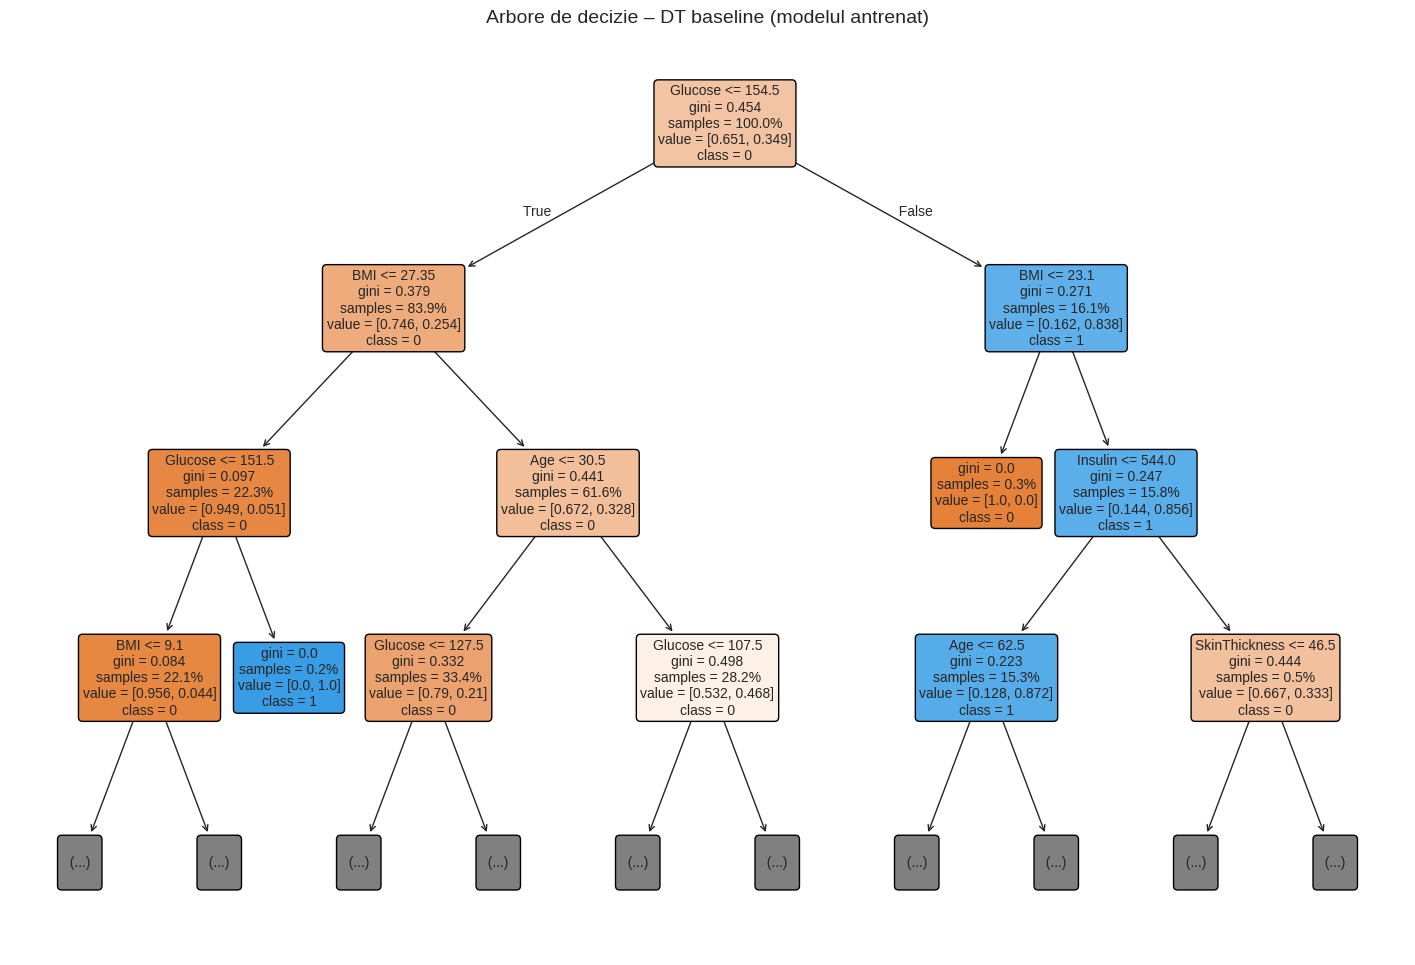

In [ ]:
# Vizualizare arbore pentru modelul deja antrenat (dt)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))  # ajustează dacă textul e înghesuit
plot_tree(
    dt,                                 # modelul tău antrenat anterior
    feature_names=list(X_train.columns),# etichete pentru noduri
    class_names=[str(c) for c in dt.classes_],  # ['0','1'] sau cum sunt clasele tale
    filled=True,                        # colorează nodurile după clasa majoritară
    rounded=True,                       # colțuri rotunjite
    proportion=True,                    # afișează proporții în loc de numere absolute
    impurity=True,                      # afișează Gini/Entropy/Log Loss (în funcție de criterion)
    fontsize=10,
    max_depth=3,
)
plt.title("Arbore de decizie – DT baseline (modelul antrenat)")
plt.show()


## 3) Tuning cu `GridSearchCV`
**TODO:**
- Definiți un `param_grid` pentru `DecisionTreeClassifier` (ex.: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`).
- Rulați două grid-uri separate: `scoring='accuracy'` și `scoring='roc_auc'`.
- Evaluați `.best_estimator_` pe test (Accuracy, ROC-AUC, CM, ROC) folosind **direct** API-ul (fără funcții custom).


In [1]:
# TODO: Definiti param_grid

# param_grid = {
#     ...
# }

In [ ]:
# TODO: Grid pe accuracy

In [ ]:
# TODO: Grid pe roc_auc

In [ ]:
# TODO: Evaluare best_auc_model

# best_auc_model = ...


## 4) RandomForestClassifier – sweep pe `n_estimators`
**TODO:**
- Pentru `n_list = [10, 50, 100, 200, 400, 800]`, antrenați `RandomForestClassifier(..., oob_score=True, n_jobs=-1, random_state=42)`
- Pentru fiecare model: calculați **Accuracy** și **ROC-AUC** pe test; salvați și `oob_score_`
- Alegeți configurarea cu **cel mai mare ROC-AUC** și evaluați în detaliu (Confusion Matrix, ROC-AUC) + **feature importances**


In [2]:
# TODO: Antreneaza cate un RandomForestClassifier pentru fiecare n_list = [...]
# TODO2: Calculeaza accuracy si ROC-AUC pe test pentru fiecare si salveaza oob_score_

# HINT: Poti face un for.. care trece prin fiecare n_list si sa salvezi toate rezultatele intr-un DataFrame la final

In [ ]:
# TODO: Alege configurarea cu cel mai mare ROC-AUC

In [ ]:
# TODO: Creeza confusion matrix, ROC curve si feature importances


## 5) Sumar de rezultate (exercițiu final)
**TODO:** construiți manual un DataFrame cu scorurile obținute (DT baseline, DT pruned, DT tuned, RF best)
folosind variabilele din celulele anterioare (`acc`, `auc`, `acc_p`, `auc_p`, `acc_t`, `auc_t`, `acc_b`, `auc_b`).
